# Refined Simultaneous Clustering (RSC) 

In [1]:
import sys
from pathlib import Path
sys.path.append('../')

from matching_clustering.utils import LapOT, lot_quad
from matching_clustering.helpers_3D import create_3D_clouds, plot_3D_point_clouds_side_by_side, plot_point_clouds_only, spectral_cluster_labels
from matching_clustering.precompute_helpers import cost_matrix_c, build_cluster_matrix
from __future__ import annotations
import numpy as np
from sklearn.cluster import SpectralClustering
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csgraph
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

### Set all the neccesary hyper parameters for all different examples

In [267]:
#@title Helper function to load all neened values for the examples 

def get_example_values(kind: str) -> dict | str:
    path_X_human = "../Data/CAPOD/class1/m1.obj"
    path_Y_human = "../Data/CAPOD/class1/m2.obj"

    path_X_dolphin = "../Data/CAPOD/class2/m13.obj"
    path_Y_dolphin = "../Data/CAPOD/class2/m16.obj"

    path_Y_dog = "../Data/CAPOD/class9/m97.obj"
    path_X_dog = "../Data/CAPOD/class9/m98.obj"

    path_X_spider = "../Data/CAPOD/class12/m133.obj"
    path_Y_spider = "../Data/CAPOD/class12/m141.obj"

    path_X_horse = "../Data/CAPOD/class13/m145.obj"
    path_Y_horse = "../Data/CAPOD/class13/m152.obj"

    examples = {
        "human": {
            "elev": 0,
            "azim_X": 260,
            "azim_Y": 270,
            "wspace": -0.36,
            "zoom_x": 1.4,
            "zoom_y": 1.4,
            "k_for_sc": 5,
            "k_for_switch": 3,
            "sigma_sc": 0.25, # Change back to 0.1
            "sigma_match": 0.077,
            "lambda_x": 10.0,
            "lambda_y": 10.0,
            "lambda": 0.2,
            "clouds": create_3D_clouds(path_X_human, path_Y_human)    
        },
        "dog": {
            "elev": 0,
            "azim_X": 190,
            "azim_Y": 190,
            "wspace": 0.0,
            "zoom_x": 1.4,
            "zoom_y": 1.2,
            "k_for_sc": 5,
            "k_for_switch": 2,
            "sigma_sc": 0.3,
            "sigma_match": 0.2,
            "lambda_x": 10.0,
            "lambda_y": 10.0,
            "lambda": 0.1,
            "clouds": tuple(cloud[::4] for cloud in create_3D_clouds(path_X_dog, path_Y_dog))  # subsample the dog point clouds to speed up computation    
        },
        "dolphin": {
            "elev": 0,
            "azim_X": 100,
            "azim_Y": 100,
            "wspace": -0.1,
            "zoom_x": 1.3,
            "zoom_y": 1.1,
            "k_for_sc": 5,
            "k_for_switch": 2,
            "sigma_sc": 0.5,
            "sigma_match": 0.2,
            "lambda_x": 10.0,
            "lambda_y": 10.0,
            "lambda": 0.3,
            "clouds": create_3D_clouds(path_X_dolphin, path_Y_dolphin)
        },
        "spider": {
            "elev": 100,
            "azim_X": 0,
            "azim_Y": 0,
            "wspace": -0.35,
            "zoom_x": 1.4,
            "zoom_y": 1.4,
            "k_for_sc": 5,
            "k_for_switch": 3,
            "sigma_sc": 0.3,
            "sigma_match": 0.1,
            "lambda_x": 10.0,
            "lambda_y": 10.0,
            "lambda": 0.3,
            "clouds": create_3D_clouds(path_X_spider, path_Y_spider)
        },
        "horse": {
            "elev": 0,
            "azim_X": 0,
            "azim_Y": 0,
            "wspace": 0.0,
            "zoom_x": 1.4,
            "zoom_y": 1.4,
            "k_for_sc": 6,
            "k_for_switch": 3,
            "sigma_sc": 0.2,
            "sigma_match": 0.025,
            "lambda_x": 10.0,
            "lambda_y": 10.0,
            "lambda": 0.6,
            "clouds": create_3D_clouds(path_X_horse, path_Y_horse)
        },
    }

    return examples.get(kind, "only 'human', 'dog', 'dolphin', 'spider', or 'horse' are valid options")

### Run the following cell for all the necessary hyperparameters for each example

In [268]:
# Specify the kind of example you want to run: "human", "dog", "dolphin", "spider", or "horse"

elev, azim_X, azim_Y, wspace, zoom_x, zoom_y, k_sc, k_switch, sigma_sc, sigma_match, lambda_x, lambda_y, lambda_entropy, clouds = get_example_values("human").values()

/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m1.obj: Load time: 0.019073009490966797
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m1.obj: Load time: 0.019073009490966797
/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m2.obj: Load time: 0.01387166976928711
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m2.obj: Load time: 0.01387166976928711
/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class9/m98.obj: Load time: 0.04921698570251465
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class9/m98.obj: Load time: 0.04921698570251465
/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class9/m97.obj: Load time: 0.0431520938873291
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class9/m97.obj: Load time: 0.0431520938873291


## Visualize the data

In [216]:
# Uncomment and run the following line to visualize the point clouds in an interactive 3D plotly figure
X,Y = clouds[0], clouds[1]
plot_3D_point_clouds_side_by_side(X, Y)

### For reference, independently apply Spectral Clustering on clouds X and Y and visualize the results

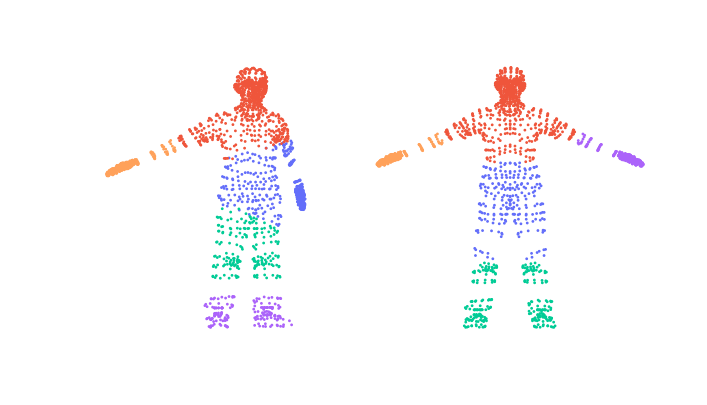

In [269]:
# Perform spectral clustering on both point clouds using the RBF kernel
sc_X = SpectralClustering(n_clusters=k_sc, affinity='rbf', gamma=1/(sigma_sc**2*2), random_state=42)
labels_X = sc_X.fit_predict(X)

sc_Y = SpectralClustering(n_clusters=k_sc, affinity='rbf', gamma=1/(sigma_sc**2*2), random_state=42)
labels_Y = sc_Y.fit_predict(Y)


# Have a path prepared to save the figure, but set save_path to output_path to save it in addition to showing it
example_name = "Humans" # set according to example: "Humans", "Dogs", "Dolphins", "Spiders", or "Horses"
base_dir = Path.cwd()  
output_path = base_dir / "Figures" / example_name / f"{example_name.lower()}_independent_spectral_clustering.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_point_clouds_only(
    X,
    Y,
    labels_X,
    labels_Y,
    elev_X=elev,
    azim_X=azim_X,
    roll_X=0,
    elev_Y=elev,
    azim_Y=azim_Y,
    roll_Y=0,
    zoom_X=zoom_x,
    zoom_Y=zoom_y,
    wspace=wspace, 
    point_size=1,
    alpha=1.0,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=False
)

## Continue with $\text{RSC}$ applied on clouds $X$ and $Y$:
### Step 1: Pre-compute  $L_X, L_Y$ and $C$ matrices and the marginal distributions $w$ and $q$.


#### Note: Since clouds $X$ and $Y$ are different embeddings of the same object, for the computation of the marginals $w$ and $q$ we adjust $\sigma$ so it will capture local geometry of both clouds (which is shared). We know that tunning $\sigma$ to be small enough will make the histograms of $w$ and $q$ almost identical (Gaussian similarity still produce connected graphs and hence, the effect of the different embeddings although small is still present even for small sigmas). Here we also note that sigma should not be too small, since we want $a$ and $b$ capture the shared local geometry of both clouds on one hand but also be of relatively low resolution. Notice that using independent spectral clustering using this value $\sigma$ does not produce a consistent result across clouds.

In [234]:
import logging
logging.basicConfig(level=logging.INFO, force=True)


# Calculate the Gaussian (RBF) kernel matrices for X and Y
W_X = rbf_kernel(X, gamma=1/(sigma_sc**2*2))
W_Y = rbf_kernel(Y, gamma=1/(sigma_sc**2*2))



# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


# can we do nearest neighbor graph
# adjust sigma values for smaller significatnce neighborhoodd

W_X_match = rbf_kernel(X, gamma=1/(sigma_match**2*2))
# np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(sigma_match**2*2))
# np.fill_diagonal(W_Y_match, 0)

L_X_match = csgraph.laplacian(W_X_match, normed=False)
L_Y_match = csgraph.laplacian(W_Y_match, normed=False)

# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()

### Calculate $C$ or load pre-computed $C$ in the cell that follows

In [287]:
C_RSC = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 1048 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 53784 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 143384 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 258584 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 399384 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done 565784 tasks      | elapsed:   42.4s
[Parallel(n_jobs=-1)]: Done 757784 tasks      | elapsed:   55.6s
[Parallel(n_jobs=-1)]: Done 975384 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1218584 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1487384 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1781784 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2101784 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2447384 tasks      | elapsed:  2.9min
[Parallel(n_jo

In [235]:
# Run this cell if you desire to load a precomputed C matrix for the example you are running. 

# Paths to the precomputed cost matrices C_RSC 
path_to_C_human = base_dir / "Precomputed" / "Humans_RSC" / "C_humans_class1_m1_m2.npy"
path_to_C_dolphin = base_dir / "Precomputed" / "Dolphins_RSC" / "C_dolphins_class2_m13_m16.npy"
path_to_C_spider = base_dir / "Precomputed" / "Spiders_RSC" / "C_spiders_class12_m133_m141.npy"
path_to_C_horse = base_dir / "Precomputed" / "Horses_RSC" / "C_horses_class13_m145_m152.npy"
path_to_C_dog = base_dir / "Precomputed" / "Dogs_RSC" / "C_dogs_class9_m97_m98.npy"

# uncomment the following line to load a precomputed cost matrix C_RSC with the desired example path
C_RSC = np.load(path_to_C_human)  # change to desired example path

### Run cell below to save the matrix $C$ for later use

In [243]:
example_RSC = "Horses_RSC" # set according to example: "Humans_RSC", "Dolphins_RSC", "Spiders_RSC", "Horses_RSC", or "Dogs_RSC"

out_dir = base_dir / "Precomputed" / example_RSC
out_dir.mkdir(parents=True, exist_ok=True)

name_for_C = "C_Horses_class13_m145_m152.npy" # set according to example. try not overwrite existing files in the Precomputed directory.
np.save(out_dir / name_for_C, C_RSC)

### Step 2: Solve $\text{LapOT}$ and refine $L_X, L_Y$ based on the switch matrices $ \pi_{switch}^X, \pi_{switch}^Y$

#### Notice:

Beyond the model's hyper parameters $\lambda,\lambda_x,~\text{and}~\lambda_y$, we also have a degree of freedom in deciding the number of clusters $k$ to which we partition the rows and columns of the optimal coupling $\pi^\star$ solving $\text{LapOT}$.

The number $k$ will partition the clouds $X$ and $Y$ into sets that share similar matches with the oposite cloud. We expect that the result will reflect the degree heirarchy present in the data (Which is dependant on sigma that was chosen). Obviously the choise of $k$ is data dependant. In reality we see that a good practice is to set k=2 or k=3 which gives the data a rough initial partition on top of which we further aplly spectral clustering.  

### Solve for $\pi^\star$ or upload a pre-computed $\pi^\star$ in a cell below

In [255]:
l =  lambda_entropy   # entropic regularization parameter
l_x = lambda_x  # Laplacian regularization parameter for X
l_y = lambda_y # Laplacian regularization parameter for Y

# Solve the LapOT problem using the fixed-point iteration method
prob = LapOT(L_X_match, L_Y_match, C_RSC, l, l_x, l_y, w=a, v=b)
pi_fp = prob.solve(method='fp', max_iter=10000, tau_scale=1, verbose=True)

Initialization: objective = -2.8848858437627327
Implement fixed point algorithm
max of entropy term :-3.0891163094013194 
 max of main term: 0.1814816521193182
Iteration 1: objective = -2.907634657282001, objective relative change = -0.007885516013901367, pi change (L1) = 0.3726956077598207
max of entropy term :-3.0891574909099173 
 max of main term: 0.18152257135215008
Iteration 2: objective = -2.907634919557767, objective relative change = -9.020244869395547e-08, pi change (L1) = 0.0011984063468770266
max of entropy term :-3.0891569115389745 
 max of main term: 0.18152199170107028
Iteration 3: objective = -2.9076349198379043, objective relative change = -9.634539909011502e-11, pi change (L1) = 3.185611786810196e-05
max of entropy term :-3.08915692799174 
 max of main term: 0.18152200815296898
Iteration 4: objective = -2.9076349198387708, objective relative change = -2.9798034220395643e-13, pi change (L1) = 1.424483195964234e-06
Terminated after 4 iterations (coupling converged)


In [201]:
# Run this cell if you desire to load a precomputed pi_fp matrix for the example you are running. 

#Paths to precomputed matrices pi_fp
path_to_pi_human = base_dir / "Precomputed" / "Humans_RSC" / "pi_fp_humans_class1_m1_m2.npy"
path_to_pi_dolphin = base_dir / "Precomputed" / "Dolphins_RSC" / "pi_fp_dolphins_class2_m13_m16.npy"
path_to_pi_spider = base_dir / "Precomputed" / "Spiders_RSC" / "pi_fp_spiders_class12_m133_m141.npy"
path_to_pi_horse = base_dir / "Precomputed" / "Horses_RSC" / "pi_fp_horses_class13_m145_m152.npy"
path_to_pi_dog = base_dir / "Precomputed" / "Dogs_RSC" / "pi_fp_dogs_class9_m97_m98.npy"


# uncomment the following line to load the precomputed pi_fp 
pi_fp = np.load(path_to_pi_horse)

### Run cell below to save the matrix $\pi^\star$ for later use

In [242]:
example_RSC = "Horses_RSC" # set according to example: "Humans_RSC", "Dolphins_RSC", "Spiders_RSC", "Horses_RSC", or "Dogs_RSC"

out_dir = base_dir / "Precomputed" / example_RSC
out_dir.mkdir(parents=True, exist_ok=True)

name_for_pi = "pi_fp_horses_class13_m145_m152.npy" # set according to example. try not overwrite existing files in the Precomputed directory.
np.save(out_dir / name_for_pi, pi_fp)

### Derive the switch matrices $\pi^X_{switch}$ and $\pi^Y_{switch}$ and update $K_X \longrightarrow \pi^X_{switch} \odot K_X,~~ K_Y \longrightarrow \pi^Y_{switch} \odot K_Y$ 

In [270]:
# derive the switch matrices 
pi_switch_x = build_cluster_matrix(pi_fp, k=k_switch)
pi_switch_y = build_cluster_matrix(pi_fp.T, k=k_switch)

# refine the similarity matrices
epsilon = 1e-6
new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

### Apply spectral clustering based on the refined matrices $K_X$ and $K_Y$

In [271]:
# perform spectral clustering on the refined similarity matrices
SC_X = SpectralClustering(
    n_clusters=k_sc,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_X = SC_X.fit_predict(new_similarity_x)

SC_Y = SpectralClustering(
    n_clusters=k_sc,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_Y = SC_Y.fit_predict(new_similarity_y)


### Visualize  the results of $\text{RSC}$ applied on clouds $X$ and $Y$

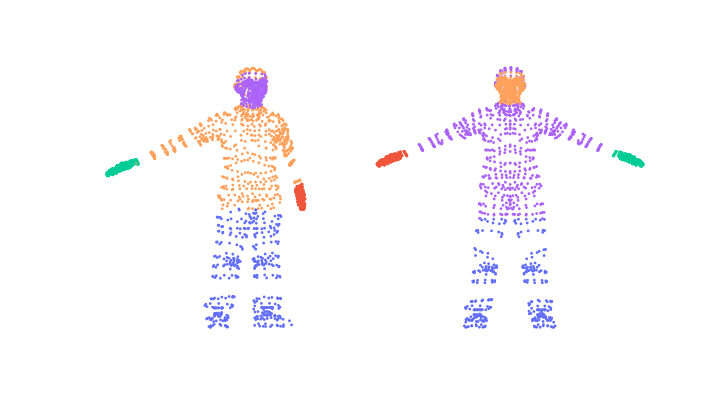

In [272]:
# Have a path prepared to save the figure, but set save_path to output_path to save it in addition to showing it

example_name = "Humans" # set according to example: "Humans", "Dogs", "Dolphins", "Spiders", or "Horses"
base_dir = Path.cwd() 
output_path = base_dir / "Figures" / example_name / f"{example_name.lower()}_RSC.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plot_point_clouds_only(
    X,
    Y,
    labels_refined_X,
    labels_refined_Y,
    elev_X=elev,
    azim_X=azim_X,
    roll_X=0,
    elev_Y=elev,
    azim_Y=azim_Y,
    roll_Y=0,
    zoom_X=zoom_x,
    zoom_Y=zoom_y,
    wspace=wspace,
    point_size=1,
    alpha=1.0,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=False
)

### Visualize the partition of $X$ and $Y$ induced by $\pi^X_{switch}$ and $\pi^Y_{switch}$

In [273]:
# Perform KMeans clustering on pi_fp and its transpose to get the switch labels for X and Y
k = k_switch  # number of clusters for the switch matrix
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
pi_switch_x_labels= kmeans.fit_predict(pi_fp)
pi_switch_y_labels = kmeans.fit_predict(pi_fp.T)

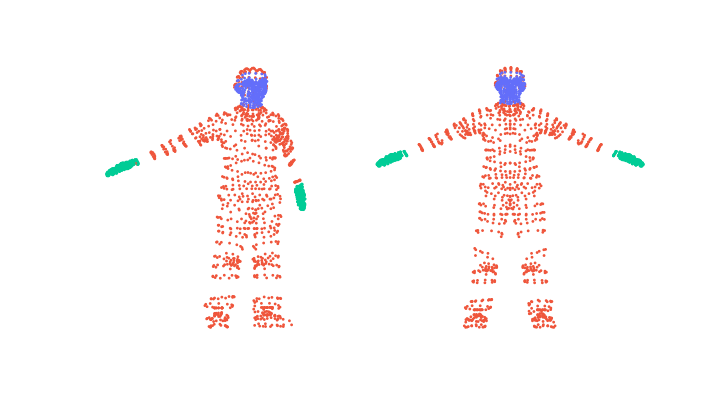

In [275]:
# Have a path prepared to save the figure, but set save_path to output_path to save it in addition to showing it

example_name = "Humans" # set according to example: "Humans", "Dogs", "Dolphins", "Spiders", or "Horses"
base_dir = Path.cwd() 
output_path = base_dir / "Figures" / example_name / f"{example_name.lower()}_according_to_switch_matrices.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plot_point_clouds_only(
    X,
    Y,
    pi_switch_x_labels,
    pi_switch_y_labels,
    elev_X=elev,
    azim_X=azim_X,
    roll_X=0,
    elev_Y=elev,
    azim_Y=azim_Y,
    roll_Y=0,
    zoom_X=zoom_x,
    zoom_Y=zoom_y,
    wspace=wspace,
    point_size=1,
    alpha=1.0,
    save_path=output_path,  # set to output_path to save the figure
    plot_clouds_only=False
)

# Now run the same for $\text{LapLOT}$ and show results of $\text{RSC}$

### Solve $\text{LapLOT}$ based on the same data as before

In [256]:
pi_low_rank = lot_quad(C_RSC, L_X_match, L_Y_match, a, b, r=10, l=l, l_x=l_x, l_y=l_y, alpha=1e-5, gamma=1)

Iteration 0, error: 6.379990886182067e-10
Objective -3.9495458613154812
Iteration 10, error: 8.340999373531105e-10
Objective -4.066500768996685
Iteration 20, error: 8.329706833819618e-10
Objective -4.066502543481142
Iteration 30, error: 8.329540378089668e-10
Objective -4.066502543706748
Iteration 40, error: 8.329524764494182e-10
Objective -4.066502543707424
Iteration 50, error: 8.329516128417302e-10
Objective -4.066502543707426
Iteration 60, error: 8.329521280410501e-10
Objective -4.066502543707426
Iteration 70, error: 8.329516899420572e-10
Objective -4.066502543707425
Iteration 80, error: 8.329516189878013e-10
Objective -4.066502543707426
Iteration 90, error: 8.329521310293823e-10
Objective -4.066502543707426
Iteration 100, error: 8.329524302014193e-10
Objective -4.066502543707426
Iteration 110, error: 8.329528858983686e-10
Objective -4.066502543707426
Iteration 120, error: 8.329530331533525e-10
Objective -4.066502543707426
Iteration 130, error: 8.329526625188398e-10
Objective -4.0665

### Derive $\pi^X_{switch}$ and $\pi^Y_{switch}$ based on the solution to $\text{LapLOT}$ and update $K_X$ and $K_Y$

In [257]:
# derive the switch matrices 
pi_switch_x = build_cluster_matrix(pi_low_rank, k=k_switch)
pi_switch_y = build_cluster_matrix(pi_low_rank.T, k=k_switch)

# refine the similarity matrices
epsilon = 1e-6
new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

### Run spectral clustering on top of the updated $K_X$ and $K_Y$

In [258]:
# perform spectral clustering on the refined similarity matrices
SC_X = SpectralClustering(
    n_clusters=k_sc,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_X = SC_X.fit_predict(new_similarity_x)

SC_Y = SpectralClustering(
    n_clusters=k_sc,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_Y = SC_Y.fit_predict(new_similarity_y)


### Plot results of $\text{RSC}$

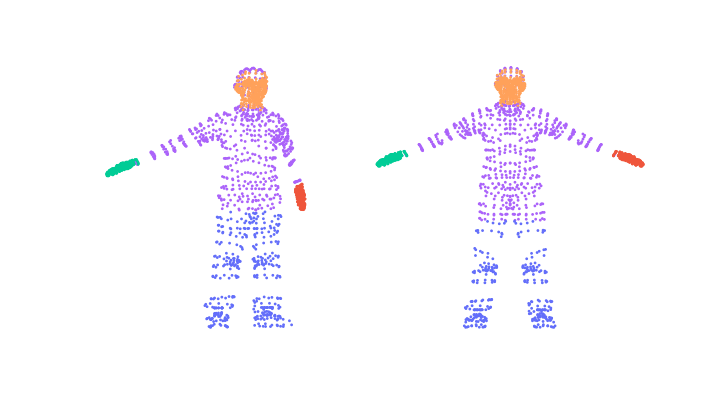

In [259]:
# Have a path prepared to save the figure, but set save_path to output_path to save it in addition to showing it

example_name = "Horses" # set according to example: "Humans", "Dogs", "Dolphins", "Spiders", or "Horses"
base_dir = Path.cwd() 
output_path = base_dir / "Figures" / example_name / f"{example_name.lower()}_RSC_LowRank.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plot_point_clouds_only(
    X,
    Y,
    labels_refined_X,
    labels_refined_Y,
    elev_X=elev,
    azim_X=azim_X,
    roll_X=0,
    elev_Y=elev,
    azim_Y=azim_Y,
    roll_Y=0,
    zoom_X=zoom_x,
    zoom_Y=zoom_y,
    wspace=wspace,
    point_size=1,
    alpha=1.0,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=False
)